# ACCESS rAM3 Scaling Results Notebook

In [1]:
%load_ext autoreload
%autoreload 2

## Experiment Setup

This notebook performs scaling studies on the Regional Nesting Suite forecast configuration. The setup steps are similar to that in the "[Run ACCESS-rAM](https://docs.access-hive.org.au/models/run-a-model/run-access-ram/)" instructions with some differences:
* `u-by395/nci_access_ram3` is checked out instead of `u-dg768`.
* The `rose-suite.conf.tutorial` is used (`cp rose-suite.conf.tutorial rose-suite.conf`)
* Single 6h chunks of in-simulation time is used (rather than 1h that comes by default).


In [11]:
## Setup experiments (to be replaced by experiment generator)
from access.config.layout_config import find_layouts_with_maxncore
from pathlib import Path
from shutil import copytree

cpus_per_node = 48 # normal
# sapphirerapids = 104

base_exp = Path.home() / "roses/u-by395"
target_dir = base_exp.parent

files_to_edit = {
    "rose-suite.conf": [
        ("rg01_rs01_m01_nproc=18,16", "rg01_rs02_m01_nproc=")
    ]
}

def replace_line_in_file(file, old_txt, new_txt):
    """Crude substitute for experiment generator's text replacement."""
    with open(file, 'r') as f:
        lines = f.readlines()
    lines = [line.replace(old_txt, new_txt) for line in lines]
    with open(file, 'w') as f:
        f.writelines(lines)

for num_nodes in (0.25,):

    total_cpus = int(num_nodes*cpus_per_node)

    # copy control exp to new location
    new_exp = target_dir / f"u-by395-rs01ncpus{total_cpus}-rs02ncpus{total_cpus}"
    copytree(base_exp, new_exp, dirs_exist_ok=True)

    # estimate a new layout
    best_layout = find_layouts_with_maxncore(
        total_cpus, 
        even_nx=True, 
        prefer_nx_greater_than_ny=True
    )
    # choose the layout that minimizes waste
    best_layout = sorted(best_layout, key=lambda x: x[0]*x[1]%48)[0]
    best_layout = int(best_layout[0]), int(best_layout[1]) # handle floats

    print(f"{num_nodes}: {best_layout}")

    # dict[str, tuple] of files with lines to replace
    files_to_edit = {
        new_exp / "rose-suite.conf": [
            ("rg01_rs01_m01_nproc=18,16", f"rg01_rs01_m01_nproc={best_layout[0]},{best_layout[1]}"),
            ("rg01_rs02_m01_nproc=18,16", f"rg01_rs02_m01_nproc={best_layout[0]},{best_layout[1]}"),
            ("CRUN_LEN=1", "CRUN_LEN=6"),
            ("CYCLE_INT_HR=1", "CYCLE_INT_HR=6")
        ],
        new_exp / "app/um/rose-app.conf": [
            ("ltimer=.false.", "ltimer=.true."),
        ],
        new_exp / "site/nci-gadi/suite-adds.rc": [
            ("-l walltime = 3600", "-l walltime = 6:0:0"),
        ]
    }

    # perform line replacement
    for file, lines_to_replace in files_to_edit.items():
        for line in lines_to_replace:
            replace_line_in_file(file, line[0], line[1])

0.25: (4, 3)


In [1]:
## Parse rAM3 profiling data
from access.profiling import RAM3Profiling
from pathlib import Path


profiling = RAM3Profiling("rg01_rs01_m01_nproc")
profiling.parse_scaling_data(
    [Path(f"/home/555/ey7514/cylc-run/u-by395-rs01ncpus{ncpus}-rs02ncpus{ncpus}") for ncpus in [24, 48, 96, 144, 288, 576]]
)
profiling.data


{'cylc_suite_log': <xarray.Dataset> Size: 180B
 Dimensions:       (ncpus: 6, region: 1)
 Coordinates:
   * ncpus         (ncpus) int64 48B 24 48 96 144 288 576
   * region        (region) <U21 84B 'pipeline_elapsed_time'
 Data variables:
     maximum time  (ncpus, region) int64 48B [s] 11052 6310 3690 2718 1878 1479,
 'cylc_tasks': <xarray.Dataset> Size: 6kB
 Dimensions:       (ncpus: 6, region: 23)
 Coordinates:
   * ncpus         (ncpus) int64 48B 24 48 96 144 288 576
   * region        (region) <U56 5kB 'install_cold_hpc_cycle20220226T0000Z' .....
 Data variables:
     maximum time  (ncpus, region) float64 1kB [s] 7.0 91.0 2.0 ... 2.0 2.0 1.0,
 'Lismore_d0198_RAL3P3_um_createbc_000_cycle20220226T0000Z_UM_total': <xarray.Dataset> Size: 164B
 Dimensions:       (ncpus: 6, region: 1)
 Coordinates:
   * ncpus         (ncpus) int64 48B 24 48 96 144 288 576
   * region        (region) <U17 68B 'um_total_walltime'
 Data variables:
     maximum time  (ncpus, region) float64 48B [s] 31.22 33.

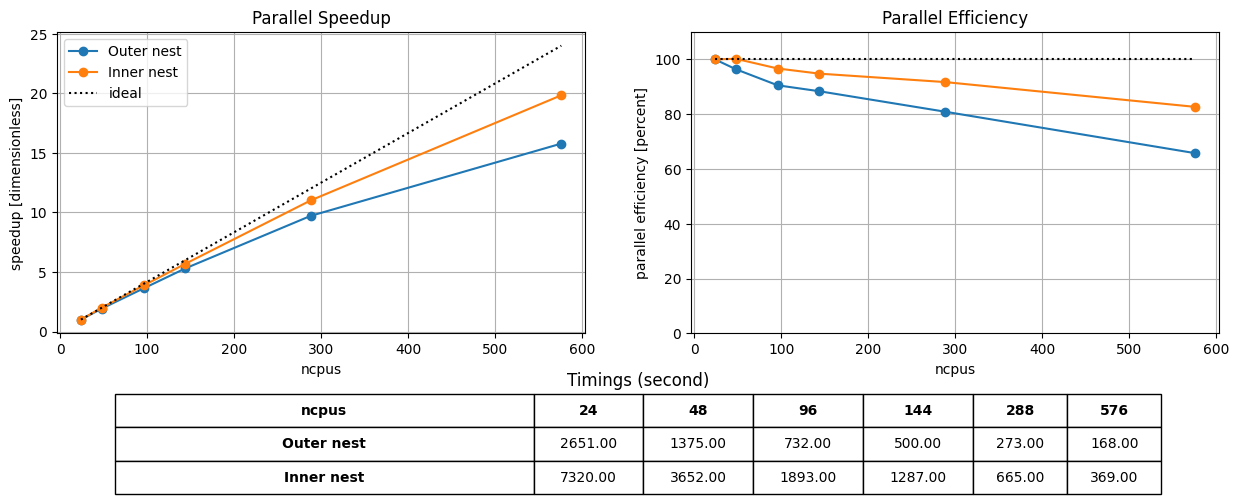

In [4]:
from access.profiling.metrics import tmax
profiling.plot_scaling_data(
    components=["cylc_tasks"],
    regions=[
        [
            "Lismore_d1100_GAL9_um_fcst_000_cycle20220226T0000Z", 
            "Lismore_d0198_RAL3P3_um_fcst_000_cycle20220226T0000Z"
        ]
    ], 
    metric=tmax,
    region_relabel_map={
        "Lismore_d1100_GAL9_um_fcst_000_cycle20220226T0000Z":"Outer nest", 
        "Lismore_d0198_RAL3P3_um_fcst_000_cycle20220226T0000Z":"Inner nest",
    }
)

In the scaling study above, `ncpus` represents the number of CPUs used at each nesting level. For example, `ncpus = 288` corresponds with the inner and outer nests both using 288 CPUs each.

Given this, when compared to the base value of 28 CPUs (half a cascadelake node), we achieve a speedup of approximately 20x at 576 CPUs (12 cascadelake nodes) for the higher resolution inner nest - representing an efficinecy of approximately 81%. For the higher-resolution outer nest, the speedup is approximately 16x corresponding to an efficiency of approx. 65%.